In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
from sklearn.datasets import make_moons
x,y=make_moons(n_samples=500, noise=None, random_state=42)
dataset=pd.DataFrame(x, columns=['a','b'])
dataset['target']=y
dataset.head()

,a,b,target
0,0.830495,-0.485529,1
1,0.605001,0.796225,0
2,0.993692,-0.499980,1
3,-0.375386,0.926868,0
4,0.255771,0.966737,0


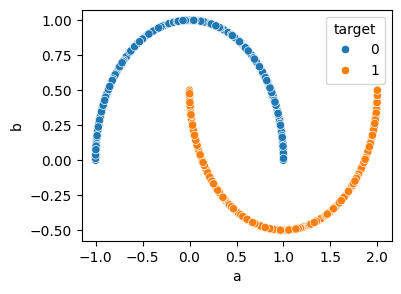

In [61]:
plt.figure(figsize=(4,3))
sns.scatterplot(x='a',y='b', data=dataset, hue='target')
plt.show()

In [62]:
x=dataset.drop(columns='target', axis=1)
y=dataset['target']

In [101]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=10)

In [102]:
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor( learning_rate=0.1, n_estimators=145, max_depth=3)
gb.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=145)

In [103]:
gb.score(x_train, y_train)*100, gb.score(x_test, y_test)*100

(99.99943804210932, 99.47509885480716)

In [93]:
from sklearn.model_selection import GridSearchCV
pdr={
    'n_estimators' : [i for i in range(100,150,5)],
    'max_depth': [i for i in range(2,5)],
     'learning_rate' : [i for i in (0.01,0.001, 0.1, 0.2,0.002, 0.02)]
}
gc=GridSearchCV(gb,pdr)
gc.fit(x_train, y_train)

GridSearchCV(estimator=GradientBoostingRegressor(n_estimators=145),
             param_grid={'learning_rate': [0.01, 0.001, 0.1, 0.2, 0.002, 0.02],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 105, 110, 115, 120, 125, 130,
                                          135, 140, 145]})

In [92]:
from sklearn.model_selection import GridSearchCV
pdr={
    'learning_rate' : [i for i in (0.01,0.001, 0.1, 0.2,0.002, 0.02)]
}
gc=GridSearchCV(gb,pdr)
gc.fit(x_train, y_train)

GridSearchCV(estimator=GradientBoostingRegressor(n_estimators=145),
             param_grid={'learning_rate': [0.01, 0.001, 0.1, 0.2, 0.002, 0.02]})

In [95]:
gc.best_params_,  gc.best_score_

({'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 145},
 0.9926086809860342)

In [94]:
gb.feature_importances_

array([0.39029118, 0.60970882])

# CONS

In [ ]:
REQUIRES ALOT OF HYPER PARAMETER TUNING WHICH AFFECTS TIME AND SPACE COMPLEXITY